In [34]:
from thermopy.eos import PengRobinson
import numpy as np
import matplotlib.pyplot as plt

# Example use case
## Van der Waals loops
Using the Peng Robinson as the equation of state, a PV isotherm graph can be generated
for methane at:<br>
   * $T > Tc$ <br>
   * $T = Tc$ <br>
   * $T < Tc$ <br>
with T = 500 K
Note: Molar Volume cannot be less than size of molecule b <br>
Methane information: <br>
   - Tc = 190.6 K <br>
   - Pc = 4599000 Pa




### Single plot at $T = 189K $

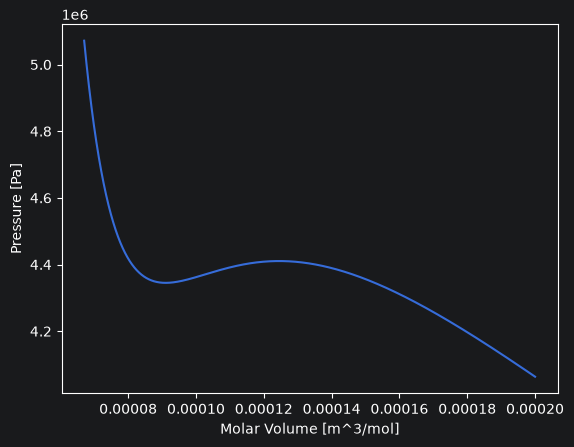

In [35]:
#instantiating the EoS class
PR = PengRobinson("methane")

#Definitions
Temp = 189 #[K]
Tc = 190.6 #[K]
Pc = 4599000 #[Pa]

b = PR.OMEGA * (8.314 * Tc) / Pc    #excluded molecule volume

#Determine pressures from volumes, volume lower bound is 1.5 * molecular volume
Vol_range = np.linspace(2.5*b, 2e-4, 5000)
Pressure_vals = [PR.P_from_TV(Temp, v) for v in Vol_range]

plt.plot(Vol_range, Pressure_vals)
plt.xlabel("Molar Volume [m^3/mol]")
plt.ylabel("Pressure [Pa]")
plt.show()



### Multiple isotherms
Generated at temperatures near Tc to demonstrate nature of curves around Tc

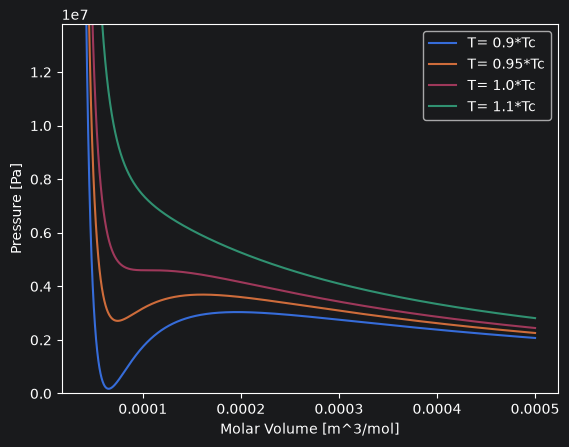

In [36]:
#instantiating the EoS class
PR = PengRobinson("methane")

#Definitions
Temp = 189 #[K]
Tc = 190.6 #[K]
Pc = 4599000 #[Pa]
b = PR.OMEGA * (8.314 * Tc) / Pc    #excluded molecule volume

T_fractions = [0.9, 0.95, 1.0, 1.1] #fractions of Tc to generate a line at
Vol_range = np.linspace(1.5*b, 5e-4, 10000)

#Determine pressures from volumes at set temperatures, volume lower bound is 1.5 * molecular volume
for T_frac in T_fractions:
    T = T_frac * Tc
    Pressure_vals = [PR.P_from_TV(T, v) for v in Vol_range]
    plt.plot(Vol_range, Pressure_vals, label=f"T= {T_frac}*Tc")


plt.xlabel("Molar Volume [m^3/mol]")
plt.ylabel("Pressure [Pa]")
plt.legend()
plt.ylim(0, Pc*3)

plt.show()